# Predictive Modeling Using Machine Learning
**Internship Project 2 — Thiranex | Data Science**

**Goal:** Predict whether the toss winner will also win the match.

**Models Used:**
- Logistic Regression
- Decision Tree
- Random Forest

**Evaluation:** Accuracy, Confusion Matrix, ROC Curve

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc
)

sns.set_theme(style='whitegrid')
print('All libraries loaded!')

All libraries loaded!


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/matches_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,toss_match_win
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,False
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri,True
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar,False
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper,False
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan,False


## 3. Feature Engineering
Create features (inputs) and target (output) for the model.

In [3]:
# Remove No Result matches
df = df[df['winner'] != 'No Result'].copy()

# Target: did toss winner also win the match? 1=Yes, 0=No
df['target'] = (df['toss_winner'] == df['winner']).astype(int)

print('Target distribution:')
print(df['target'].value_counts())
print()
print('1 = Toss winner WON the match')
print('0 = Toss winner LOST the match')

Target distribution:
target
1    554
0    536
Name: count, dtype: int64

1 = Toss winner WON the match
0 = Toss winner LOST the match


In [4]:
# Select features for prediction
features = ['toss_decision', 'season', 'city']

df_model = df[features + ['target']].copy()

# Fill any remaining missing cities
df_model['city'] = df_model['city'].fillna('Unknown')

# Encode categorical columns (text -> numbers)
le = LabelEncoder()
df_model['toss_decision'] = le.fit_transform(df_model['toss_decision'])  # bat=0, field=1
df_model['city'] = le.fit_transform(df_model['city'])

print('Features after encoding:')
df_model.head()

Features after encoding:


,toss_decision,season,city,target
0,1,2008,2,0
1,0,2008,7,1
2,0,2008,10,0
3,0,2008,27,0
4,0,2008,24,0


## 4. Split Data into Train & Test

In [5]:
X = df_model[features]
y = df_model['target']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 872
Testing samples  : 218


## 5. Train 3 Models

In [6]:
# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy : {lr_acc*100:.2f}%')

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy       : {dt_acc*100:.2f}%')

# Model 3: Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy       : {rf_acc*100:.2f}%')

Logistic Regression Accuracy : 59.17%
Decision Tree Accuracy       : 55.50%
Random Forest Accuracy       : 52.29%


## 6. Model Comparison Chart

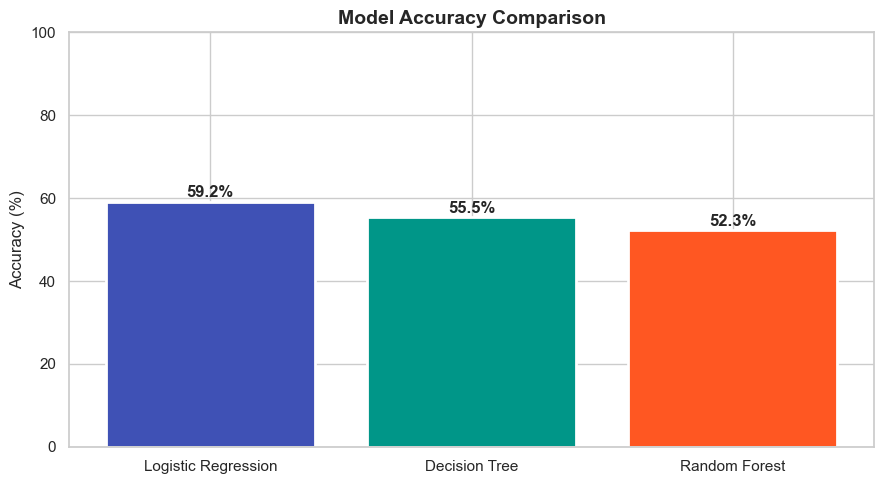

Saved: ml_model_comparison.png


In [7]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc*100, dt_acc*100, rf_acc*100]
colors = ['#3F51B5', '#009688', '#FF5722']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', linewidth=2)
plt.ylim(0, 100)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../output/ml_model_comparison.png', dpi=150)
plt.show()
print('Saved: ml_model_comparison.png')

## 7. Confusion Matrix (Best Model — Random Forest)

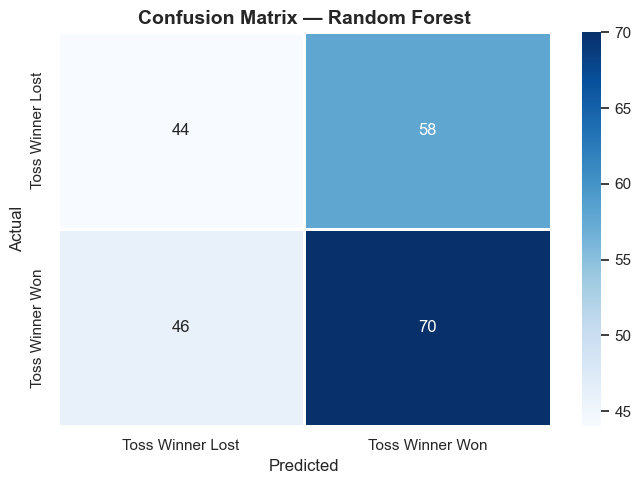


Classification Report:
                  precision    recall  f1-score   support

Toss Winner Lost       0.49      0.43      0.46       102
 Toss Winner Won       0.55      0.60      0.57       116

        accuracy                           0.52       218
       macro avg       0.52      0.52      0.52       218
    weighted avg       0.52      0.52      0.52       218



In [8]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Toss Winner Lost', 'Toss Winner Won'],
            yticklabels=['Toss Winner Lost', 'Toss Winner Won'],
            linewidths=2, linecolor='white')
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../output/ml_confusion_matrix.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['Toss Winner Lost', 'Toss Winner Won']))

## 8. ROC Curve (All 3 Models)

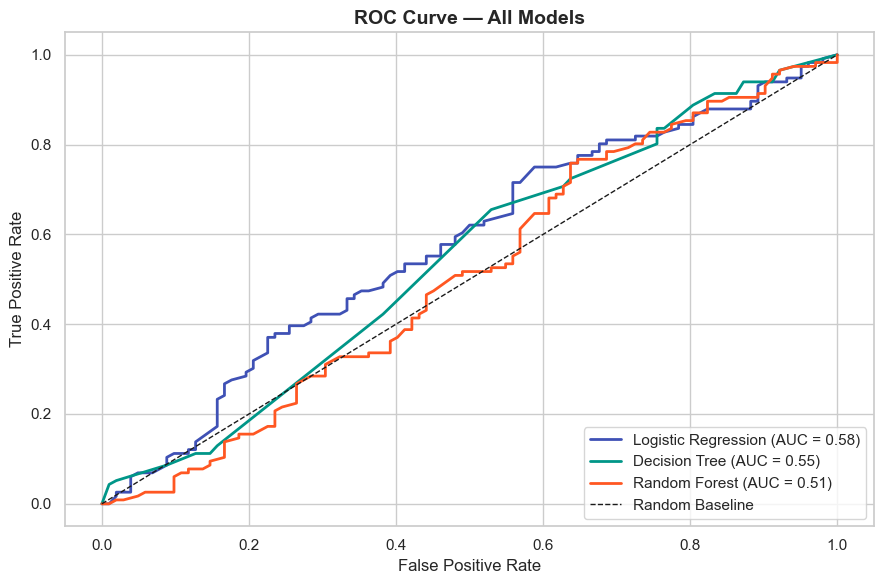

Saved: ml_roc_curve.png


In [9]:
plt.figure(figsize=(9, 6))

for model, pred_proba, name, color in [
    (lr,  lr.predict_proba(X_test)[:,1],  'Logistic Regression', '#3F51B5'),
    (dt,  dt.predict_proba(X_test)[:,1],  'Decision Tree',       '#009688'),
    (rf,  rf.predict_proba(X_test)[:,1],  'Random Forest',       '#FF5722'),
]:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')

plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../output/ml_roc_curve.png', dpi=150)
plt.show()
print('Saved: ml_roc_curve.png')

## 9. Feature Importance (Random Forest)

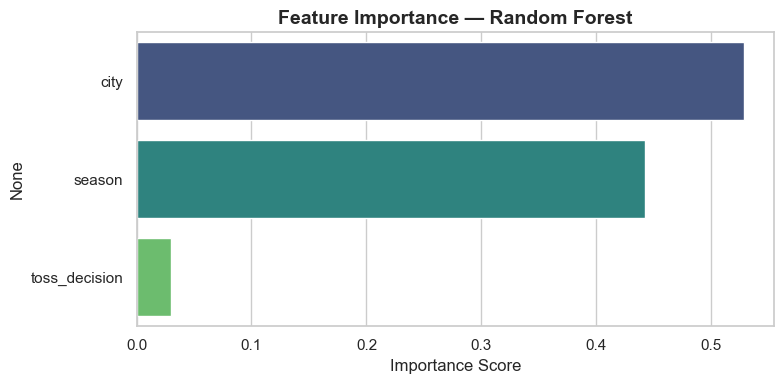


Insight: The most important feature for predicting match outcome is: city


In [10]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../output/ml_feature_importance.png', dpi=150)
plt.show()

print('\nInsight: The most important feature for predicting match outcome is:',
      importance.index[0])

## 10. Summary

In [11]:
print('='*50)
print('PROJECT SUMMARY')
print('='*50)
print(f'Dataset        : IPL Matches (1095 rows)')
print(f'Target         : Did toss winner win the match?')
print(f'Features used  : Toss Decision, Season, City')
print()
print(f'Logistic Regression : {lr_acc*100:.2f}%')
print(f'Decision Tree       : {dt_acc*100:.2f}%')
print(f'Random Forest       : {rf_acc*100:.2f}%')
print()
best = models[accuracies.index(max(accuracies))]
print(f'Best Model : {best} with {max(accuracies):.2f}% accuracy')
print()
print('Key Finding: Toss outcome alone is a weak predictor of')
print('match result — the game is decided by player performance.')

PROJECT SUMMARY
Dataset        : IPL Matches (1095 rows)
Target         : Did toss winner win the match?
Features used  : Toss Decision, Season, City

Logistic Regression : 59.17%
Decision Tree       : 55.50%
Random Forest       : 52.29%

Best Model : Logistic Regression with 59.17% accuracy

Key Finding: Toss outcome alone is a weak predictor of
match result — the game is decided by player performance.


## What Each Term Means

| Term | Simple Meaning |
|---|---|
| **Train data** | Data the model learns from (80%) |
| **Test data** | Data used to check model performance (20%) |
| **Accuracy** | How often the model predicts correctly |
| **Confusion Matrix** | Table showing correct vs wrong predictions |
| **ROC Curve** | Graph showing how good the model is overall |
| **AUC** | Score for ROC — closer to 1.0 = better model |
| **Feature Importance** | Which input affected the prediction the most |